
Distribution table: count (percentage)


,train,val,test
Images in split (% of all imgs),3788 (80.0%),710 (15.0%),238 (5.0%)
0 (abiotic),1285 (7.0%),254 (7.8%),79 (7.2%)
1 (insect),11370 (62.2%),1899 (58.6%),691 (63.3%)
2 (disease),5626 (30.8%),1085 (33.5%),321 (29.4%)


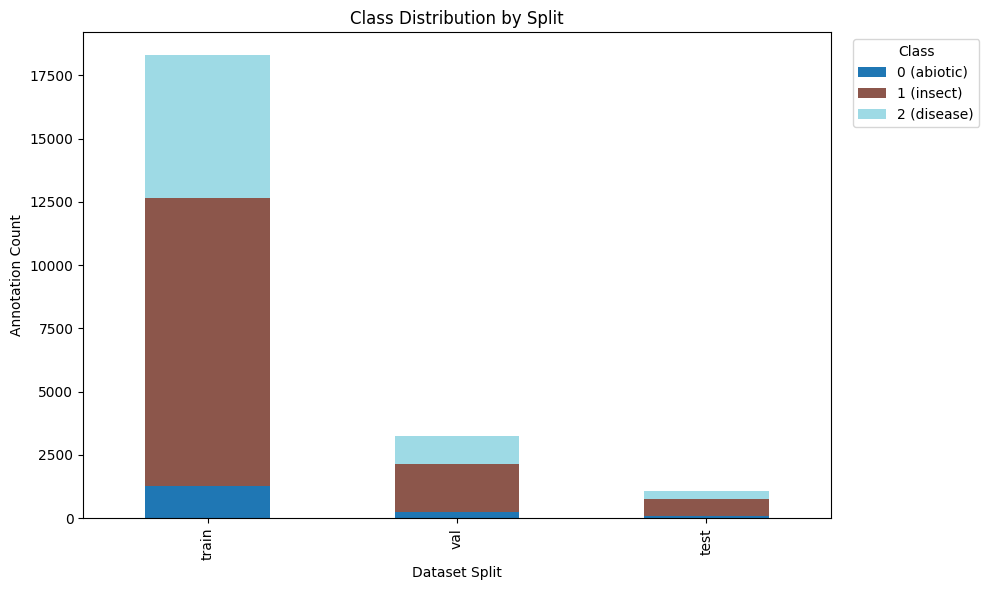

In [8]:
import importlib
import src.dataset as dataset
import pandas as pd
import matplotlib.pyplot as plt

importlib.reload(dataset)

data_root = "data/raw"
splits = ("train", "val", "test")
class_names = {0: "abiotic", 1: "insect", 2: "disease"}

split_counts = dataset.get_split_class_distribution(data_root, splits=splits)
split_image_counts = dataset.get_split_image_counts(data_root, splits=splits)

dist_df = pd.DataFrame(split_counts).fillna(0).astype(int)
dist_df = dist_df.reindex(sorted(dist_df.index), fill_value=0)
dist_df.index = [f"{idx} ({class_names.get(idx, 'unknown')})" for idx in dist_df.index]

split_totals = dist_df.sum(axis=0)
class_pct_df = dist_df.divide(split_totals.where(split_totals != 0, 1), axis=1) * 100
class_table = dist_df.astype(str) + " (" + class_pct_df.round(1).astype(str) + "%)"

image_counts = pd.Series(split_image_counts).reindex(dist_df.columns, fill_value=0).astype(int)
total_images = int(image_counts.sum())
image_split_pct = (image_counts / (total_images if total_images else 1) * 100).round(1)

image_summary_row = pd.DataFrame(
    [[f"{image_counts[split]} ({image_split_pct[split]}%)" for split in class_table.columns]],
    index=["Images in split (% of all imgs)"],
    columns=class_table.columns,
)
formatted_table = pd.concat([image_summary_row, class_table], axis=0)

print("\nDistribution table: count (percentage)")
display(formatted_table)

if not dist_df.empty:
    ax = dist_df.T.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        colormap="tab20",
    )
    ax.set_title("Class Distribution by Split")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Annotation Count")
    ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No label annotations found in the configured split folders.")